Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data into pd graph

In [2]:
trainingdata = pd.read_csv("Salary_Data.csv")

x_train = trainingdata["YearsExperience"].values
y_train = trainingdata["Salary"].values

Visualizing data

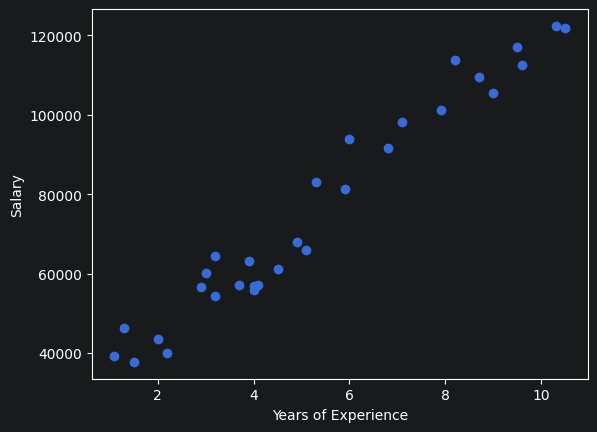

In [3]:
plt.scatter(x_train, y_train)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

Implementation steps:
1. Create cost function
2. Create gradient function
3. Create gradient descent
4. Assemble

Cost function

In [4]:
def cost_function(x: list[float], y:list[float], w:float, b:float) -> float:
    """
    Calculate mean squared error(mse) based on values given
    x: a list containing the X values
    y: a list containing the Y values
    w: the weight
    b: the bias
    returns the MSE
    formula: 1/2m * sum((w * xi + b - yi)^2
    """
    # m is the number of data points
    m = len(x)
    total_error = 0.0
    # calculate inside of sum
    for i in range(m):
        # Formula inside sum
        total_error += ((w*x[i] + b - y[i]) ** 2)
    # divide by 2m
    return total_error / (2*m)

Gradient functionm

In [5]:
def gradient_function(x: list[float], y:list[float], w:float, b:float) -> tuple[float, float]:
    """
    Calculate gradient of cost function grad(C(w,b))
    hard coded formula ig
    x: a list containing the X values
    y: a list containing the Y values
    w: the weight
    b: the bias
    returns a tuple containing the w and b components of grad(C(w,b))
    formulas:
    - w component: (1/m) * sum(xi * (w * xi + b - yi))
    - b component: (1/m) * sum((w * xi + b - yi))
    """
    # m is the number of data points
    m = len(x)
    deltaw = 0.0
    deltab = 0.0
    # sum
    for i in range(m):
        # formulas for deltas
        deltaw += (w * x[i] + b - y[i]) * x[i]
        deltab += (w * x[i] + b - y[i])

    return (deltaw / m, deltab / m)

Gradient Descent Function

In [22]:
def gradient_descent_function(x:list[float], y:list[float], alpha:float, num_iters:int) -> tuple[float,float]:
    """
    Attempts to calculate the optimal weight and bias values for the linear regression model
    x: a list containing the X values
    y: a list containing the Y values
    alpha: the learning rate, higher = faster convergence, but more inaccurate
    num_iters: the number of iterations to run gradient descent for, too low means we might not reach gradient
    """
    w = 0.0
    b = 0.0
    for i in range(num_iters):
        # calculate gradient
        grad = gradient_function(x, y, w, b)
        w = w - (alpha * grad[0])
        b = b - (alpha * grad[1])
        # output cost each time
        print(f"Iteration {i+1}, cost: {cost_function(x, y, w, b)}")

    return w,b

Deploy functions

In [12]:
learning_rate = 0.01
num_iters = 1000
final_w, final_b = gradient_descent_function(x_train, y_train, learning_rate, num_iters)
print(f"Final W: {final_w}, Final B: {final_b})")

Iteration 1, cost: 1344612525.8413548
Iteration 2, cost: 582933639.1249903
Iteration 3, cost: 278595825.9816312
Iteration 4, cost: 156901936.81054005
Iteration 5, cost: 108149191.53202362
Iteration 6, cost: 88526795.5063979
Iteration 7, cost: 80538511.12387824
Iteration 8, cost: 77197055.8093798
Iteration 9, cost: 75711992.7100282
Iteration 10, cost: 74968933.0700283
Iteration 11, cost: 74522833.02695376
Iteration 12, cost: 74195957.63300419
Iteration 13, cost: 73917324.17093243
Iteration 14, cost: 73658582.39816462
Iteration 15, cost: 73408407.74554898
Iteration 16, cost: 73162275.01092048
Iteration 17, cost: 72918374.39160368
Iteration 18, cost: 72675980.51521407
Iteration 19, cost: 72434801.09739313
Iteration 20, cost: 72194716.82236984
Iteration 21, cost: 71955677.46187694
Iteration 22, cost: 71717660.38925987
Iteration 23, cost: 71480654.01166648
Iteration 24, cost: 71244651.15349762
Iteration 25, cost: 71009646.41398282
Iteration 26, cost: 70775635.11185879
Iteration 27, cost: 70

plot graph

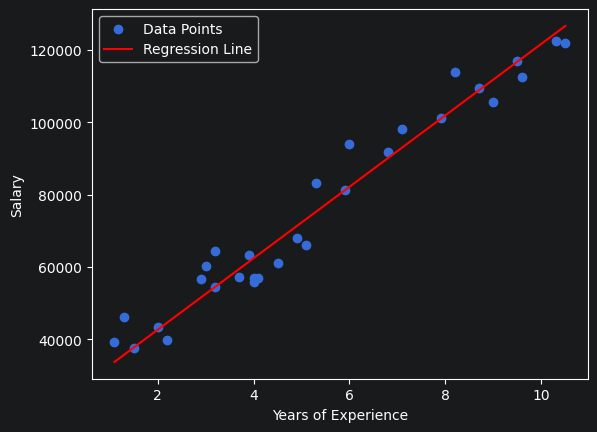

In [14]:
plt.scatter(x_train, y_train, label = "Data Points")
plt.plot(x_train, final_w * x_train + final_b, label = "Regression Line", color = "red")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

Testing with new dataset

In [28]:
trainingdata2 = pd.read_csv("test.csv")
x_train2 = trainingdata2["x"].values
y_train2 = trainingdata2["y"].values

learning_rate = 0.00005
num_iters = 5000
final_w2, final_b2 = gradient_descent_function(x_train2, y_train2, learning_rate, num_iters)
print(f"Final W: {final_w}, Final B: {final_b})")

Iteration 1, cost: 1193.9789504130624
Iteration 2, cost: 823.4634060875562
Iteration 3, cost: 568.371822243182
Iteration 4, cost: 392.74702817465277
Iteration 5, cost: 271.8333239955652
Iteration 6, cost: 188.58696947705732
Iteration 7, cost: 131.2737344288371
Iteration 8, cost: 91.81486639927826
Iteration 9, cost: 64.64832679562836
Iteration 10, cost: 45.94477767338278
Iteration 11, cost: 33.067806348830985
Iteration 12, cost: 24.20230223639363
Iteration 13, cost: 18.098602694770932
Iteration 14, cost: 13.896343220848072
Iteration 15, cost: 11.003182286794829
Iteration 16, cost: 9.01130612958156
Iteration 17, cost: 7.639944184420175
Iteration 18, cost: 6.695792259059272
Iteration 19, cost: 6.045764783185797
Iteration 20, cost: 5.5982353475673134
Iteration 21, cost: 5.290121238960971
Iteration 22, cost: 5.077991434112466
Iteration 23, cost: 4.931944654463057
Iteration 24, cost: 4.831394545088234
Iteration 25, cost: 4.762167865594788
Iteration 26, cost: 4.7145066600949175
Iteration 27, 

plot

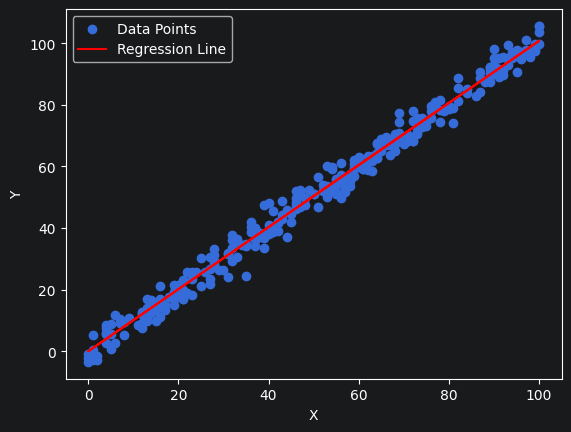

In [29]:
plt.scatter(x_train2, y_train2, label = "Data Points")
plt.plot(x_train2, final_w2 * x_train2 + final_b2, label = "Regression Line", color = "red")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()